# Демо А · Правдоподобие руками

**Тезис:** метод максимального правдоподобия — это буквально поиск максимума кривой.

Подбросили монету 100 раз, выпало 63 орла. Какова вероятность орла $p$?

$$L(p) = p^{63}(1-p)^{37}, \qquad \log L(p) = 63\log p + 37\log(1-p)$$

Ниже та же кривая для трёх объёмов данных с одной и той же долей орлов (0.6–0.63). Максимум на месте, но **пик становится острее с ростом данных**. Это уверенность оценки.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 12})

def log_likelihood(p, heads, n):
    """log L(p) для heads орлов из n бросков."""
    return heads * np.log(p) + (n - heads) * np.log(1 - p)

def likelihood_normalized(p, heads, n):
    """L(p), отнормированная на максимум, чтобы кривые были сравнимы по форме."""
    ll = log_likelihood(p, heads, n)
    return np.exp(ll - ll.max())

p = np.linspace(0.001, 0.999, 2000)
experiments = [(6, 10), (63, 100), (630, 1000)]   # (орлов, бросков)

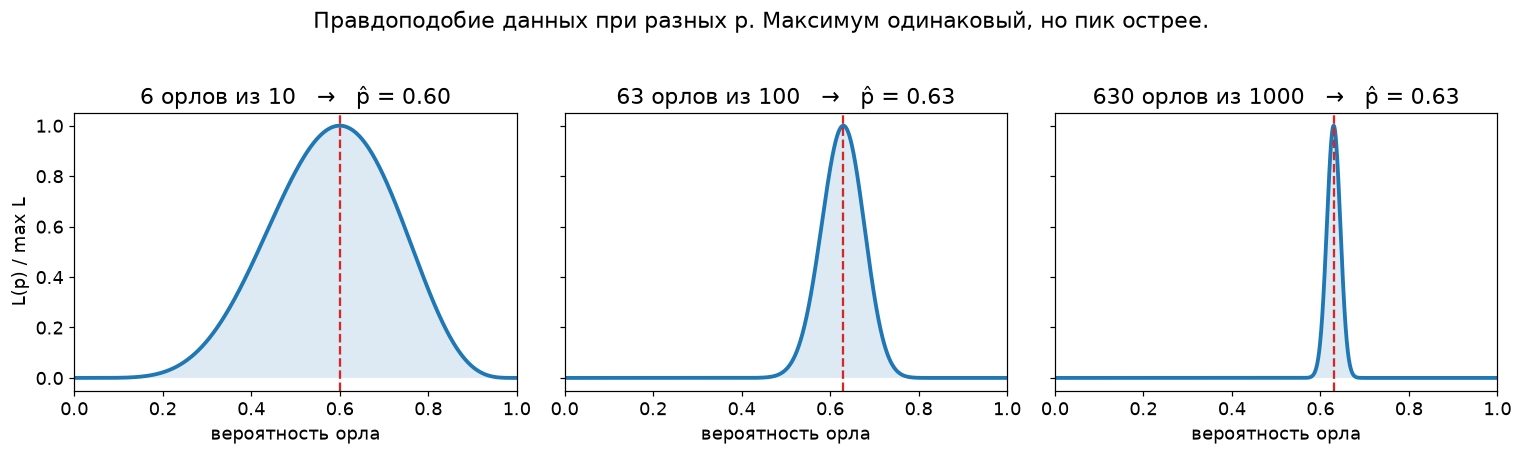

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (heads, n) in zip(axes, experiments):
    L = likelihood_normalized(p, heads, n)
    p_hat = heads / n
    ax.plot(p, L, lw=2.5)
    ax.axvline(p_hat, ls="--", color="tab:red", lw=1.5)
    ax.fill_between(p, L, alpha=0.15)
    ax.set_title(f"{heads} орлов из {n}   →   p̂ = {p_hat:.2f}")
    ax.set_xlabel("вероятность орла")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("L(p) / max L")
fig.suptitle("Правдоподобие данных при разных p. Максимум одинаковый, но пик острее.", y=1.03)
plt.tight_layout()
plt.show()

## Аналитически та же точка

$$\frac{d\log L}{dp} = \frac{63}{p} - \frac{37}{1-p} = 0 \;\Rightarrow\; 63(1-p) = 37p \;\Rightarrow\; \hat p = 0.63$$

Проверим численно, что максимум кривой совпадает с аналитическим ответом.

In [6]:
for heads, n in experiments:
    ll = log_likelihood(p, heads, n)
    p_numeric = p[ll.argmax()]
    print(f"{heads:>4} из {n:<5}  аналитически: {heads/n:.3f}   численно: {p_numeric:.3f}")

   6 из 10     аналитически: 0.600   численно: 0.600
  63 из 100    аналитически: 0.630   численно: 0.630
 630 из 1000   аналитически: 0.630   численно: 0.630


## Почему логарифм

Само правдоподобие для 1000 бросков — число порядка $10^{-290}$: произведение тысячи вероятностей. Логарифм превращает произведение в сумму, а максимум при этом не сдвигается.

In [7]:
heads, n = 630, 1000
p_hat = heads / n
L_raw = p_hat**heads * (1 - p_hat)**(n - heads)
print(f"L(p̂) для {heads} из {n}:   {L_raw:.3e}")
print(f"log L(p̂):                 {log_likelihood(p_hat, heads, n):.1f}")

L(p̂) для 630 из 1000:   6.595e-287
log L(p̂):                 -659.0


## Вывод

> Больше данных — острее пик. Это и есть уверенность оценки. 

**Что дальше:** этот же приём — «при каких параметрах наши данные наиболее вероятны» — даёт MSE (если шум гауссовский), кросс-энтропию (если ответ «да/нет») и функцию потерь языковой модели (если ответ — «один из 150 000 токенов»).